In [1]:
# -------------------------
# 1. Install Required Libraries
# -------------------------
!pip install -q imbalanced-learn scikit-learn pandas numpy xgboost lightgbm optuna shap

# -------------------------
# 2. Import Libraries
# -------------------------
from sklearn.metrics import matthews_corrcoef
import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder, StandardScaler, PolynomialFeatures
from sklearn.feature_selection import SelectKBest, f_classif, RFECV
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
from sklearn.metrics import confusion_matrix, cohen_kappa_score
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, AdaBoostClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from imblearn.over_sampling import BorderlineSMOTE
from sklearn.model_selection import StratifiedKFold, GridSearchCV
import shap
import optuna
import time
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from sklearn.metrics import confusion_matrix
from sklearn.calibration import calibration_curve
import matplotlib.pyplot as plt

import warnings
warnings.filterwarnings("ignore")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 413.9/413.9 kB 29.5 MB/s eta 0:00:00


In [2]:
# -------------------------
# 3. Upload Dataset
# -------------------------
from google.colab import files
uploaded = files.upload()  # upload hepatitis_c_dataset.csv
df = pd.read_csv(list(uploaded.keys())[0], encoding='latin1')

rows_before = df.shape[0]

df = df.dropna()

rows_after = df.shape[0]

rows_removed = rows_before - rows_after

print("Rows before cleaning:", rows_before)
print("Rows after cleaning:", rows_after)
print("Rows removed:", rows_removed)

le_sex = LabelEncoder()
df['Sex'] = le_sex.fit_transform(df['Sex'])

X = df.drop(columns=['Category'])
y = df['Category']

# Convert target to numeric if needed
y = pd.factorize(y)[0]


Saving HepatitisCdata.csv to HepatitisCdata.csv
Rows before cleaning: 615
Rows after cleaning: 589
Rows removed: 26


In [ ]:
# ============================================================
# Ablation Study
# ============================================================

import warnings
warnings.filterwarnings("ignore")

from collections import Counter




# ============================================================
# Classifiers
# ============================================================

models = {

    "Random Forest":
        RandomForestClassifier(n_estimators=300, random_state=42),

    "Gradient Boosting":
        GradientBoostingClassifier(n_estimators=200, random_state=42),

    "XGBoost":
        XGBClassifier(eval_metric="logloss", random_state=42),

    "LightGBM":
        LGBMClassifier(random_state=42),
    "SVM":
        SVC(probability=True, random_state=42),

    "KNN":
        KNeighborsClassifier()
}


# ============================================================
# Nested Cross Validation
# ============================================================

outer_cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

inner_cv = StratifiedKFold(
    n_splits=3,
    shuffle=True,
    random_state=42
)


results = []


# ============================================================
# Experiment Loop
# ============================================================

for train_idx, test_idx in outer_cv.split(X, y):

    X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
    y_train, y_test = y[train_idx], y[test_idx]


    # --------------------------------------------------------
    # Standardization
    # --------------------------------------------------------

    scaler = StandardScaler()

    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)


    # ============================================================
    # Configuration 1 : RAW
    # ============================================================

    X_train_raw = X_train_scaled
    X_test_raw = X_test_scaled


    # ============================================================
    # Configuration 2 : Polynomial
    # ============================================================

    poly = PolynomialFeatures(
        degree=2,
        interaction_only=True,
        include_bias=False
    )

    X_train_poly = poly.fit_transform(X_train_scaled)
    X_test_poly = poly.transform(X_test_scaled)


    # ============================================================
    # Configuration 3 : ANORFE
    # ============================================================

    k = min(30, X_train_scaled.shape[1])

    anova = SelectKBest(f_classif, k=k)

    X_train_anova = anova.fit_transform(X_train_scaled, y_train)
    X_test_anova = anova.transform(X_test_scaled)

    rf_estimator = RandomForestClassifier(n_estimators=200, random_state=42)

    rfe = RFECV(
        estimator=rf_estimator,
        step=1,
        cv=inner_cv,
        scoring="accuracy",
        n_jobs=-1
    )

    X_train_anorfe = rfe.fit_transform(X_train_anova, y_train)
    X_test_anorfe = rfe.transform(X_test_anova)


    # ============================================================
    # Configuration 4 : BSMOTE
    # ============================================================

    class_counts = Counter(y_train)
    min_class = min(class_counts.values())

    k_neighbors = min(5, min_class - 1)

    bsmote = BorderlineSMOTE(
        kind="borderline-1",
        k_neighbors=k_neighbors,
        random_state=42
    )

    X_train_bsmote, y_train_bsmote = bsmote.fit_resample(X_train_scaled, y_train)


    # ============================================================
    # Configuration 5 : ANORFE + Polynomial
    # ============================================================

    X_train_poly2 = poly.fit_transform(X_train_scaled)
    X_test_poly2 = poly.transform(X_test_scaled)

    k = min(30, X_train_poly2.shape[1])

    anova2 = SelectKBest(f_classif, k=k)

    X_train_anova2 = anova2.fit_transform(X_train_poly2, y_train)
    X_test_anova2 = anova2.transform(X_test_poly2)

    rfe2 = RFECV(
        estimator=rf_estimator,
        step=1,
        cv=inner_cv,
        scoring="accuracy",
        n_jobs=-1
    )

    X_train_anorfe_poly = rfe2.fit_transform(X_train_anova2, y_train)
    X_test_anorfe_poly = rfe2.transform(X_test_anova2)


    # ============================================================
    # Configuration 6 : Hepa-HISS
    # Polynomial → ANORFE → BSMOTE
    # ============================================================

    X_train_poly3 = poly.fit_transform(X_train_scaled)
    X_test_poly3 = poly.transform(X_test_scaled)

    k = min(30, X_train_poly3.shape[1])

    anova3 = SelectKBest(f_classif, k=k)

    X_train_anova3 = anova3.fit_transform(X_train_poly3, y_train)
    X_test_anova3 = anova3.transform(X_test_poly3)

    rfe3 = RFECV(
        estimator=rf_estimator,
        step=1,
        cv=inner_cv,
        scoring="accuracy",
        n_jobs=-1
    )

    X_train_rfe = rfe3.fit_transform(X_train_anova3, y_train)
    X_test_rfe = rfe3.transform(X_test_anova3)

    X_train_hepa, y_train_hepa = bsmote.fit_resample(X_train_rfe, y_train)


    # ============================================================
    # Configuration Dictionary
    # ============================================================

    configs = {

        "Raw": (X_train_raw, y_train, X_test_raw),

        "Raw + Polynomial": (X_train_poly, y_train, X_test_poly),

        "Raw + ANORFE": (X_train_anorfe, y_train, X_test_anorfe),

        "Raw + BSMOTE": (X_train_bsmote, y_train_bsmote, X_test_raw),

        "ANORFE + Polynomial": (X_train_anorfe_poly, y_train, X_test_anorfe_poly),

        "Hepa-HISS": (X_train_hepa, y_train_hepa, X_test_rfe)
    }


    # ============================================================
    # Model Training
    # ============================================================

    for clf_name, model in models.items():

        for config_name, (Xtr, ytr, Xte) in configs.items():

            model.fit(Xtr, ytr)

            preds = model.predict(Xte)

            prob = model.predict_proba(Xte)

            acc = accuracy_score(y_test, preds)

            precision = precision_score(y_test, preds, average="weighted")

            recall = recall_score(y_test, preds, average="weighted")

            f1 = f1_score(y_test, preds, average="weighted")

            auc = roc_auc_score(y_test, prob, multi_class="ovr", average="weighted")

                        # Confusion Matrix
            cm = confusion_matrix(y_test, preds)

            # Specificity for multiclass
            specificity_list = []

            for i in range(len(cm)):

                TP = cm[i, i]
                FN = cm[i, :].sum() - TP
                FP = cm[:, i].sum() - TP
                TN = cm.sum() - (TP + FN + FP)

                specificity = TN / (TN + FP) if (TN + FP) > 0 else 0

                specificity_list.append(specificity)

            specificity = np.mean(specificity_list)

            # Cohen's Kappa
            kappa = cohen_kappa_score(y_test, preds)

            # MCC
            mcc = matthews_corrcoef(y_test, preds)

            results.append([
            clf_name,
            config_name,
            acc,
            precision,
            recall,
            f1,
            auc,
            specificity,
            kappa,
            mcc
              ])


# ============================================================
# Results Table
# ============================================================

results_df = pd.DataFrame(
    results,
    columns=[
        "Classifier",
        "Configuration",
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score",
        "AUC",
        "Specificity",
        "Cohen Kappa",
        "MCC"
    ]
)

final_results = results_df.groupby(
    ["Classifier","Configuration"]
).mean().reset_index()

print("\n===== Final Nested CV Results =====\n")

print(final_results.sort_values(by="Accuracy", ascending=False))


===== Final Nested CV Results =====

           Classifier        Configuration  Accuracy  Precision    Recall  \
35            XGBoost     Raw + Polynomial  0.952470   0.937657  0.952470   
22      Random Forest         Raw + BSMOTE  0.950746   0.937793  0.950746   
16           LightGBM         Raw + BSMOTE  0.950732   0.949127  0.950732   
12           LightGBM  ANORFE + Polynomial  0.949051   0.937889  0.949051   
21      Random Forest         Raw + ANORFE  0.947356   0.935413  0.947356   
32            XGBoost                  Raw  0.947342   0.934041  0.947342   
14           LightGBM                  Raw  0.947327   0.936744  0.947327   
17           LightGBM     Raw + Polynomial  0.947327   0.929778  0.947327   
28                SVM         Raw + BSMOTE  0.945661   0.941735  0.945661   
2   Gradient Boosting                  Raw  0.945661   0.940867  0.945661   
15           LightGBM         Raw + ANORFE  0.945632   0.941307  0.945632   
20      Random Forest                 

In [3]:
##Propose Hepa -HISS
## ============================================================
# NESTED CROSS VALIDATION (Reviewer Comment Addressed)
# ============================================================

from sklearn.model_selection import StratifiedKFold
# Store predictions across folds (for confusion matrix)
all_true = {}
all_pred = {}
outer_cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)


inner_cv = StratifiedKFold(
    n_splits=3,
    shuffle=True,
    random_state=42
)

results = []

import time

training_times = {
    "Random Forest": [],
    "Gradient Boosting": [],
    "XGBoost": [],
    "LightGBM": [],
    "SVM": [],
    "KNN": []
}

misclassified_cases_all = []
for train_idx, test_idx in outer_cv.split(X, y):

    X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
    y_train, y_test = y[train_idx], y[test_idx]

    # ------------------------------------------------
    # Standardization
    # ------------------------------------------------

    scaler = StandardScaler()

    X_train = scaler.fit_transform(X_train)
    X_test = scaler.transform(X_test)

    # ============================================================
    # STEP 1 : Polynomial Feature Expansion
    # ============================================================

    poly = PolynomialFeatures(
        degree=2,
        interaction_only=True,
        include_bias=False
    )

    X_train_poly = poly.fit_transform(X_train)
    X_test_poly = poly.transform(X_test)

    print("Polynomial Features:", X_train_poly.shape[1])

    # ============================================================
    # STEP 2 : ANOVA Feature Selection
    # ============================================================

    k = min(30, X_train_poly.shape[1])

    anova = SelectKBest(
        score_func=f_classif,
        k=k
    )

    X_train_anova = anova.fit_transform(X_train_poly, y_train)
    X_test_anova = anova.transform(X_test_poly)

    print("Features after ANOVA:", X_train_anova.shape[1])

    # ============================================================
    # STEP 3 : RFE (ANORFE Hybrid)
    # ============================================================

    rf_estimator = RandomForestClassifier(
        n_estimators=200,
        random_state=42
    )

    rfe = RFECV(
        estimator=rf_estimator,
        step=1,
        cv=5,
        scoring="accuracy",
        n_jobs=-1
    )

    X_train_rfe = rfe.fit_transform(X_train_anova, y_train)
    X_test_rfe = rfe.transform(X_test_anova)

    print("Final Selected Features:", X_train_rfe.shape[1])

    # ============================================================
    # STEP 4 : Borderline SMOTE
    # ============================================================

    from collections import Counter

    class_counts_before = Counter(y_train)

    min_class = min(class_counts_before.values())

    k_neighbors = min(5, min_class - 1)

    bsmote = BorderlineSMOTE(
      kind="borderline-1",
      k_neighbors=k_neighbors,
      random_state=42
    )

    X_train_bal, y_train_bal = bsmote.fit_resample(X_train_rfe, y_train)
    class_counts_after = Counter(y_train_bal)

    synthetic_generated = {
        cls: class_counts_after[cls] - class_counts_before.get(cls, 0)
        for cls in class_counts_after
    }

    print("\nClass distribution BEFORE BSMOTE:", class_counts_before)
    print("Class distribution AFTER BSMOTE:", class_counts_after)
    print("Synthetic samples generated:", synthetic_generated)

    # ============================================================
    # STEP 5 : Ensemble Classifiers
    # ============================================================

    models = {

        "Random Forest":
            RandomForestClassifier(
                  random_state=42
            ),

        "Gradient Boosting":
            GradientBoostingClassifier(
                    random_state=42
            ),

        "XGBoost":
            XGBClassifier(
                random_state=42
            ),

        "LightGBM":
            LGBMClassifier(
                      max_depth=-1,
                random_state=42, verbose=-1
            ),

        "SVM":
            SVC(probability=True, random_state=42),

        "KNN":
            KNeighborsClassifier()
    }
    for name in models.keys():
        all_true[name] = []
        all_pred[name] = []

    # ============================================================
    # Model Training and Evaluation
    # ============================================================



    for name, model in models.items():

        grid = GridSearchCV(
            estimator=model,
            param_grid={},        # empty grid = only CV validation
            cv=inner_cv,
            scoring="accuracy",
            n_jobs=-1
        )

        start_time = time.time()

        grid.fit(X_train_bal, y_train_bal)

        end_time = time.time()

        training_times[name].append(end_time - start_time)

        best_model = grid.best_estimator_

        preds = best_model.predict(X_test_rfe)
        # store predictions for global confusion matrix
        # store predictions for each classifier
        all_true[name].extend(y_test)
        all_pred[name].extend(preds)
        prob = best_model.predict_proba(X_test_rfe)

        # ------------------------------------------------
    # Collect Misclassified Samples
    # ------------------------------------------------

        for i in range(len(preds)):

          if preds[i] != y_test[i]:

              misclassified_cases_all.append({
                "Model": name,
                "Actual": y_test[i],
                "Predicted": preds[i],
                "Sample_Index": i
            })

        acc = accuracy_score(y_test, preds)

        precision = precision_score(y_test, preds, average="weighted")

        recall = recall_score(y_test, preds, average="weighted")

        f1 = f1_score(y_test, preds, average="weighted")

        auc = roc_auc_score(y_test, prob, multi_class="ovr", average="weighted")

            # Confusion Matrix
        cm = confusion_matrix(y_test, preds)

        # Specificity calculation for multiclass
        specificity_list = []

        for i in range(len(cm)):

            TP = cm[i,i]
            FN = np.sum(cm[i,:]) - TP
            FP = np.sum(cm[:,i]) - TP
            TN = np.sum(cm) - (TP + FN + FP)

            specificity = TN / (TN + FP)
            specificity_list.append(specificity)

        specificity = np.mean(specificity_list)

        # Cohen Kappa
        kappa = cohen_kappa_score(y_test, preds)
        # MCC
        mcc = matthews_corrcoef(y_test, preds)

        results.append([
        name,
        acc,
        precision,
        recall,
        f1,
        auc,
        specificity,
        kappa, mcc
        ])

# ------------------------------------------------
# Results Table
# ------------------------------------------------

results_df = pd.DataFrame(
    results,
    columns=[
    "Model",
    "Accuracy",
    "Precision",
    "Recall",
    "F1 Score",
    "AUC",
    "Specificity",
    "Cohen Kappa", "MCC"
])

# Average performance across folds
#final_results = results_df.groupby("Model").mean().reset_index()

final_results = results_df.loc[
    results_df.groupby("Model")["Accuracy"].idxmax()
].reset_index(drop=True)

print("\n===== Hepa-HISS Final Results (Average Across 5 Folds) =====\n")

print(final_results.sort_values(by="Accuracy", ascending=False))




print("\n===== Runtime Benchmarks (seconds) =====")

for model_name, times in training_times.items():

    avg_time = np.mean(times)

    print(f"{model_name}: {avg_time:.4f} sec")


# ============================================================
# Misclassified Case Study (Reviewer Comment)
# ============================================================

misclassified_df = pd.DataFrame(misclassified_cases_all)

print("\n===== Misclassified Samples =====\n")

print(misclassified_df.head())

print("Total Misclassified Samples:", len(misclassified_df))

Polynomial Features: 78
Features after ANOVA: 30
Final Selected Features: 28

Class distribution BEFORE BSMOTE: Counter({np.int64(0): 420, np.int64(4): 19, np.int64(2): 16, np.int64(3): 10, np.int64(1): 6})
Class distribution AFTER BSMOTE: Counter({np.int64(0): 420, np.int64(1): 420, np.int64(2): 420, np.int64(3): 420, np.int64(4): 420})
Synthetic samples generated: {np.int64(0): 0, np.int64(1): 414, np.int64(2): 404, np.int64(3): 410, np.int64(4): 401}
Polynomial Features: 78
Features after ANOVA: 30
Final Selected Features: 14

Class distribution BEFORE BSMOTE: Counter({np.int64(0): 421, np.int64(4): 19, np.int64(2): 16, np.int64(3): 10, np.int64(1): 5})
Class distribution AFTER BSMOTE: Counter({np.int64(0): 421, np.int64(1): 421, np.int64(2): 421, np.int64(3): 421, np.int64(4): 421})
Synthetic samples generated: {np.int64(0): 0, np.int64(1): 416, np.int64(2): 405, np.int64(3): 411, np.int64(4): 402}
Polynomial Features: 78
Features after ANOVA: 30
Final Selected Features: 10

Class 


===== Confusion Matrices (Hepa-HISS) =====

Confusion Matrix for Random Forest


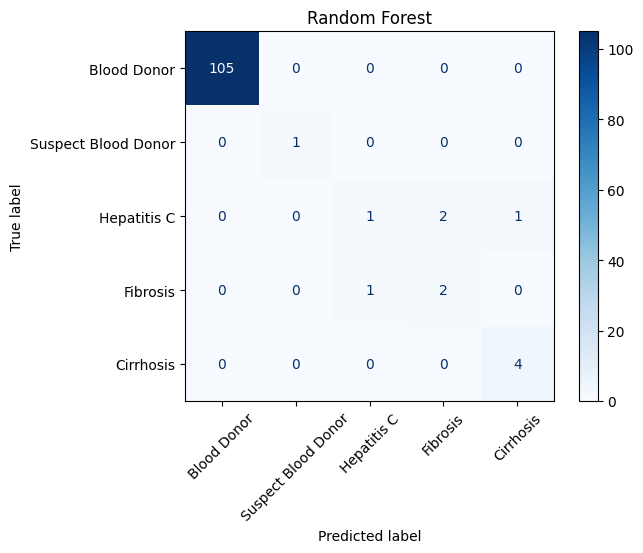


Confusion Matrix for Gradient Boosting


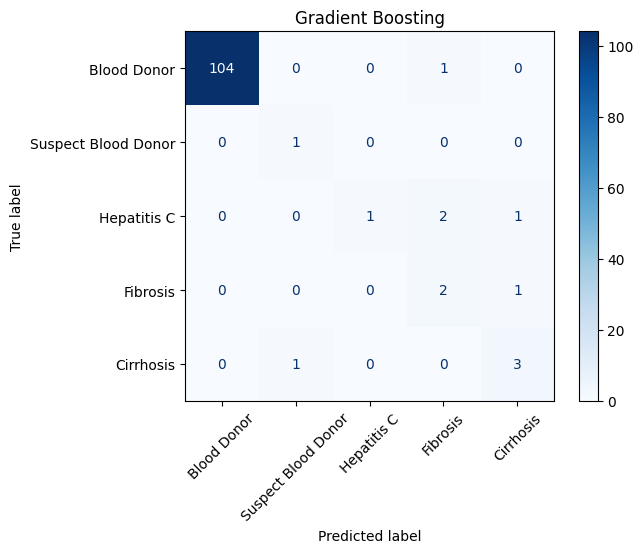


Confusion Matrix for XGBoost


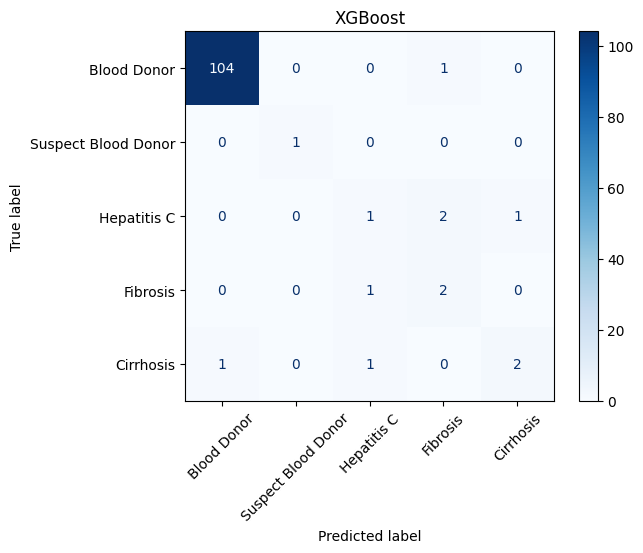


Confusion Matrix for LightGBM


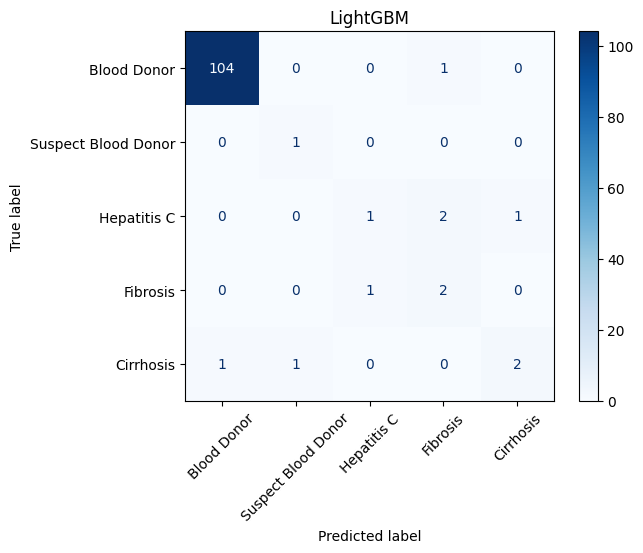


Confusion Matrix for SVM


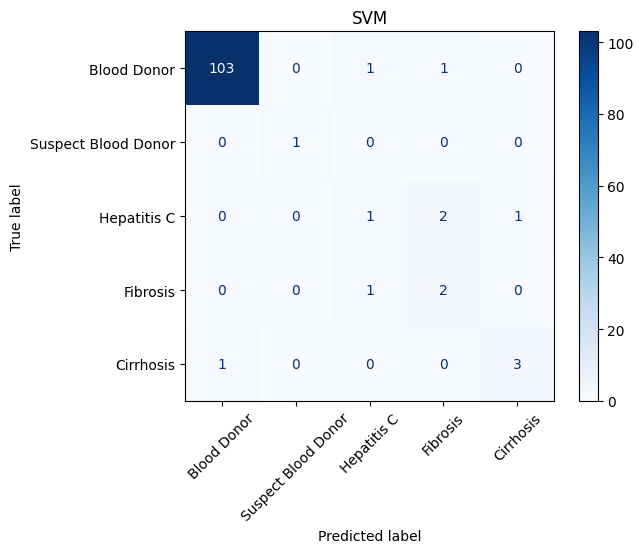


Confusion Matrix for KNN


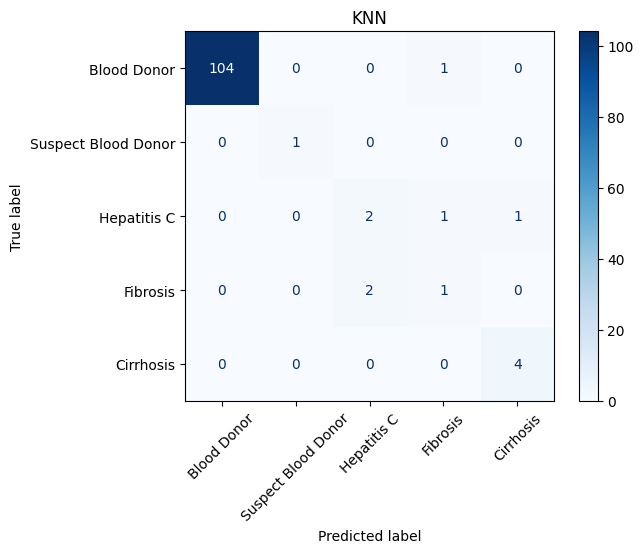

In [6]:
class_labels = [
      "Blood Donor",
    "Suspect Blood Donor",
    "Hepatitis C",
    "Fibrosis",
    "Cirrhosis"
]

# ============================================================
# Confusion Matrices for Hepa-HISS
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt
# ============================================================

print("\n===== Confusion Matrices (Hepa-HISS) =====")

for model_name in all_true.keys():

    cm = confusion_matrix(all_true[model_name], all_pred[model_name])

    print(f"\nConfusion Matrix for {model_name}")

    disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=class_labels
)

    disp.plot(cmap="Blues", xticks_rotation=45)

    plt.title(model_name)

    plt.show()

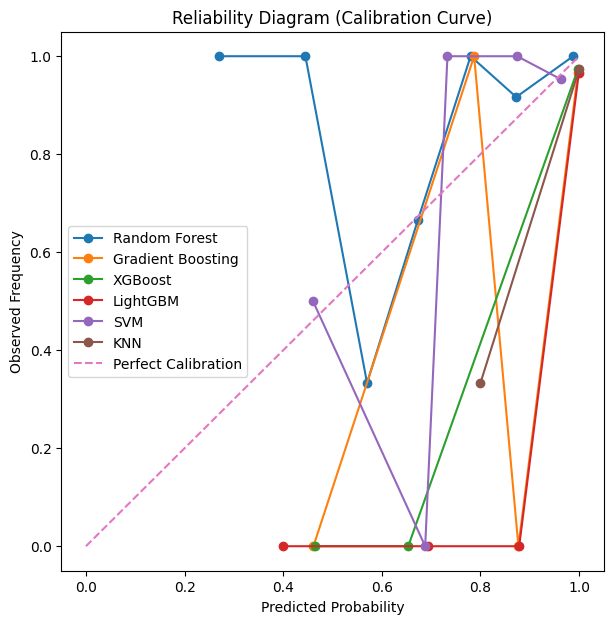

In [ ]:
#Relaiblity Diagram
plt.figure(figsize=(7,7))

for name, model in models.items():

    model.fit(X_train_bal, y_train_bal)

    prob = model.predict_proba(X_test_rfe)

    # use maximum probability for multiclass
    prob_max = prob.max(axis=1)

    preds = model.predict(X_test_rfe)

    true = (preds == y_test).astype(int)

    frac_pos, mean_pred = calibration_curve(true, prob_max, n_bins=10)

    plt.plot(mean_pred, frac_pos, marker='o', label=name)

plt.plot([0,1],[0,1], linestyle="--", label="Perfect Calibration")

plt.xlabel("Predicted Probability")
plt.ylabel("Observed Frequency")
plt.title("Reliability Diagram (Calibration Curve)")
plt.legend()
plt.show()


===== Misclassified Samples =====
           Model  Actual  Predicted  Sample_Index
0  Random Forest       1          0           106
1  Random Forest       2          3           107
2  Random Forest       2          3           108
3  Random Forest       2          3           109
4  Random Forest       3          2           111
Total Misclassified Samples: 224

Selected Misclassified Case:
Model           Random Forest
Actual                      1
Predicted                   0
Sample_Index              106
Name: 0, dtype: object


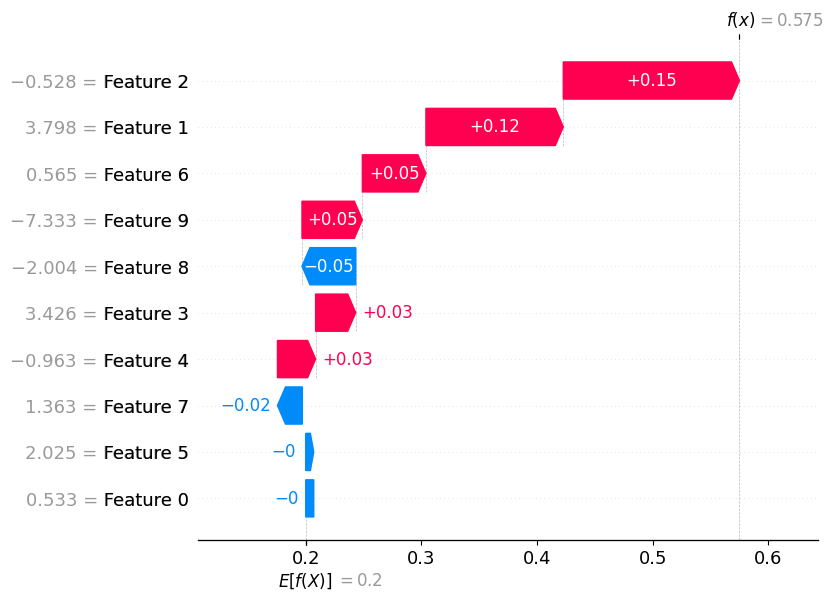

In [ ]:
# ============================================================
# Misclassified Case Study + SHAP Explanation (Random Forest)
# ============================================================

import shap
import pandas as pd
from sklearn.ensemble import RandomForestClassifier

misclassified_df = pd.DataFrame(misclassified_cases_all)

print("\n===== Misclassified Samples =====")
print(misclassified_df.head())
print("Total Misclassified Samples:", len(misclassified_df))

if len(misclassified_df) > 0:

    case = misclassified_df.iloc[0]

    sample_index = int(case["Sample_Index"])

    print("\nSelected Misclassified Case:")
    print(case)

    # Train Random Forest for explanation
    rf_model = RandomForestClassifier(
        n_estimators=200,
        random_state=42
    )

    rf_model.fit(X_train_bal, y_train_bal)

    # Create SHAP explainer
    explainer = shap.TreeExplainer(rf_model)

    # Select misclassified sample
    sample = X_test_rfe[sample_index].reshape(1, -1)

    # Compute SHAP values
    shap_values = explainer(sample)

    # Get predicted class
    predicted_class = rf_model.predict(sample)[0]

    # Plot waterfall for predicted class
    shap.plots.waterfall(shap_values[0][:, predicted_class])

In [ ]:
#Test Set Class Ratio
from collections import Counter

test_class_counts_all = []

for train_idx, test_idx in outer_cv.split(X, y):
    y_test = y[test_idx]
    test_class_counts_all.append(Counter(y_test))



# Compute average ratio across folds
import numpy as np

all_classes = sorted(set(y))
avg_ratios = {c: np.mean([fold.get(c,0)/sum(fold.values()) for fold in test_class_counts_all])
              for c in all_classes}


avg_ratios_clean = {int(k): float(v) for k, v in avg_ratios.items()}
print("Average test set class ratios across folds:", avg_ratios_clean)

Average test set class ratios across folds: {0: 0.8930465015210778, 1: 0.011878893234825438, 2: 0.033956250905403454, 3: 0.020382442416340723, 4: 0.0407359119223526}


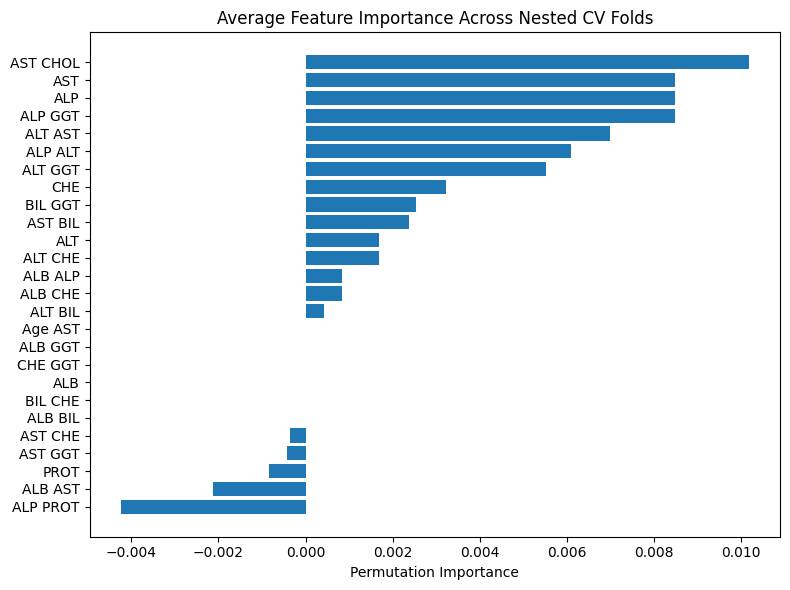

In [ ]:
# ============================================================
# Nested CV Feature Importance (Robust Version)
# ============================================================

from sklearn.inspection import permutation_importance
import pandas as pd
import matplotlib.pyplot as plt

feature_importance_dict = {}

for train_idx, test_idx in outer_cv.split(X, y):

    X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
    y_train, y_test = y[train_idx], y[test_idx]

    scaler = StandardScaler()
    X_train = scaler.fit_transform(X_train)
    X_test = scaler.transform(X_test)

    poly = PolynomialFeatures(degree=2, interaction_only=True, include_bias=False)
    X_train_poly = poly.fit_transform(X_train)
    X_test_poly = poly.transform(X_test)

    k = min(30, X_train_poly.shape[1])
    anova = SelectKBest(score_func=f_classif, k=k)

    X_train_anova = anova.fit_transform(X_train_poly, y_train)
    X_test_anova = anova.transform(X_test_poly)

    rf_estimator = RandomForestClassifier(n_estimators=200, random_state=42)

    rfe = RFECV(estimator=rf_estimator, step=1, cv=3, scoring="accuracy", n_jobs=-1)

    X_train_rfe = rfe.fit_transform(X_train_anova, y_train)
    X_test_rfe = rfe.transform(X_test_anova)

    # Feature names after selection
    feature_names = poly.get_feature_names_out(X.columns)
    feature_names = feature_names[anova.get_support()]
    feature_names = feature_names[rfe.support_]

    # Train model
    model = RandomForestClassifier(random_state=42)
    model.fit(X_train_rfe, y_train)

    perm = permutation_importance(
        model,
        X_test_rfe,
        y_test,
        n_repeats=10,
        random_state=42,
        n_jobs=-1
    )

    for feature, importance in zip(feature_names, perm.importances_mean):

        if feature not in feature_importance_dict:
            feature_importance_dict[feature] = []

        feature_importance_dict[feature].append(importance)

# Average importance
importance_df = pd.DataFrame({
    "Feature": list(feature_importance_dict.keys()),
    "Importance": [sum(v)/len(v) for v in feature_importance_dict.values()]
})

importance_df = importance_df.sort_values(by="Importance", ascending=True)

# Plot
plt.figure(figsize=(8,6))
plt.barh(importance_df["Feature"], importance_df["Importance"])
plt.xlabel("Permutation Importance")
plt.title("Average Feature Importance Across Nested CV Folds")
plt.tight_layout()
plt.show()

In [ ]:
# ============================================================
# Regenerate Prediction Explanation (Hepa-HISS)
# ============================================================

import eli5

# Train final Hepa-HISS model on full dataset
X_scaled = scaler.fit_transform(X)

X_poly = poly.fit_transform(X_scaled)

X_anova = anova.fit_transform(X_poly, y)

X_rfe = rfe.fit_transform(X_anova, y)

# Apply BSMOTE
from collections import Counter
class_counts = Counter(y)

min_class = min(class_counts.values())
k_neighbors = min(5, min_class - 1)

bsmote = BorderlineSMOTE(
    kind="borderline-1",
    k_neighbors=k_neighbors,
    random_state=42
)

X_bal, y_bal = bsmote.fit_resample(X_rfe, y)

# Train final model
final_model = RandomForestClassifier(
    n_estimators=300,
    random_state=42
)

final_model.fit(X_bal, y_bal)

# Get feature names after selection
feature_names = poly.get_feature_names_out(X.columns)
feature_names = feature_names[anova.get_support()]
feature_names = feature_names[rfe.support_]

# Select a sample to explain
sample_index = 0
sample = X.iloc[[sample_index]]

# Apply same preprocessing
sample_scaled = scaler.transform(sample)
sample_poly = poly.transform(sample_scaled)
sample_anova = anova.transform(sample_poly)
sample_rfe = rfe.transform(sample_anova)

# Prediction probabilities
print("Prediction probabilities:")
print(final_model.predict_proba(sample_rfe))

# Explanation figure
eli5.show_prediction(
    final_model,
    sample_rfe[0],
    feature_names=feature_names
)

Prediction probabilities:
[[0.9        0.00333333 0.07666667 0.02       0.        ]]


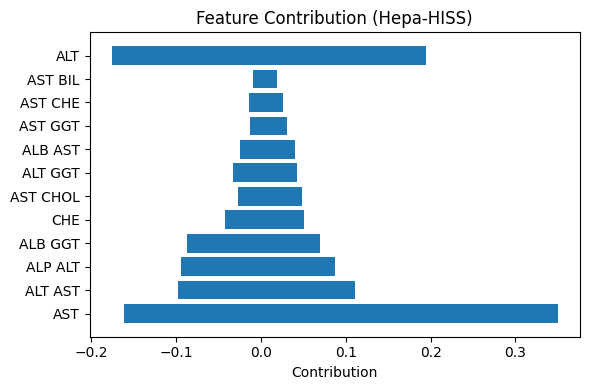

In [ ]:
import matplotlib.pyplot as plt

weights = eli5.explain_prediction_df(
    final_model,
    sample_rfe[0],
    feature_names=feature_names
)

weights = weights[weights.feature != "<BIAS>"]

plt.figure(figsize=(6,4))
plt.barh(weights.feature, weights.weight)
plt.xlabel("Contribution")
plt.title("Feature Contribution (Hepa-HISS)")
plt.tight_layout()
plt.show()

In [ ]:
pip install eli5

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 108.4/108.4 kB 4.0 MB/s eta 0:00:00
